In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import os

def find_file(filename, search_path):
    for root, dirs, files in os.walk(search_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

# 1. Automatically locate the file anywhere in your project
filename = "tanzania.csv"
# We search starting from two levels up to be safe
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
file_path = find_file(filename, project_root)

if file_path:
    print(f"Found it! Loading from: {file_path}")
    df = pd.read_csv(file_path)
else:
    # Last resort: list everything so we can see where it is
    print("Files in current folder:", os.listdir("."))
    raise FileNotFoundError(f"I searched everywhere but couldn't find {filename}. Is it spelled exactly like that?")

# 2. Add Country & Clean NASA Sentinel Values
df['Country'] = 'Tanzania'
df.replace(-999, np.nan, inplace=True)

# 3. Date Parsing
# NASA uses YEAR and Day of Year (DOY). 
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month

# 4. Outlier Detection (Z-score > 3)
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR']
df_numeric = df[cols_to_check].dropna()
z_scores = np.abs(stats.zscore(df_numeric))

print("\n--- Success! Tanzania Data Profiled ---")
print(f"Total rows: {len(df)}")
print(f"Outlier Counts (|Z| > 3):\n{(z_scores > 3).sum()}")

# 5. Export Clean Data to a safe spot
df.to_csv("tanzania_clean.csv", index=False)
df.head()

Found it! Loading from: c:\Users\HP\Desktop\10acadamey\week0\-climate-challenge-week0\.github\workflows\tanzania.csv

--- Success! Tanzania Data Profiled ---
Total rows: 4108
Outlier Counts (|Z| > 3):
88


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


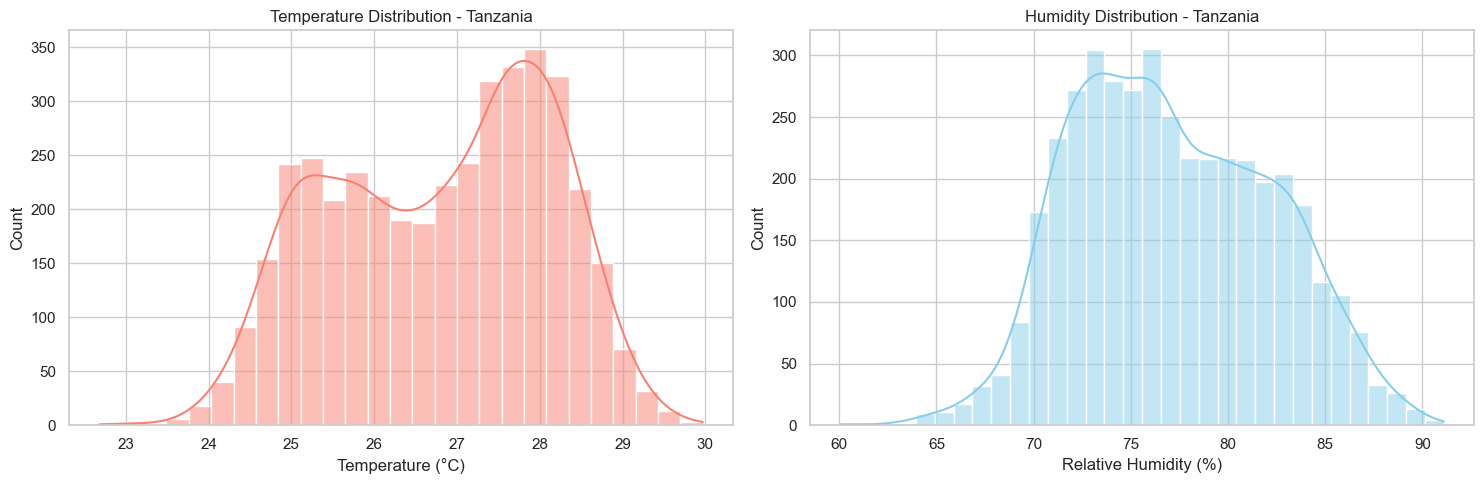

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a figure for distributions
plt.figure(figsize=(15, 5))

# Plot 1: Temperature Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['T2M'], kde=True, color='salmon')
plt.title(f'Temperature Distribution - {df["Country"].iloc[0]}')
plt.xlabel('Temperature (°C)')

# Plot 2: Humidity Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['RH2M'], kde=True, color='skyblue')
plt.title(f'Humidity Distribution - {df["Country"].iloc[0]}')
plt.xlabel('Relative Humidity (%)')

plt.tight_layout()
plt.show()

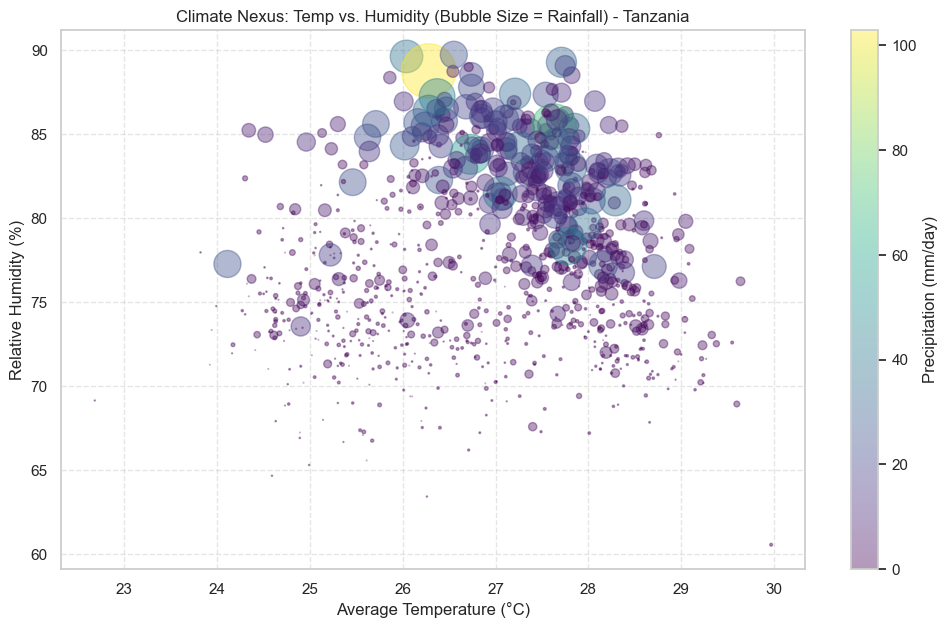

In [4]:
plt.figure(figsize=(12, 7))

# Sample data if it's too large to keep the plot clean
plot_df = df.sample(n=min(1000, len(df)))

scatter = plt.scatter(
    plot_df['T2M'], 
    plot_df['RH2M'], 
    s=plot_df['PRECTOTCORR'] * 15,  # Bubble size = Rainfall
    alpha=0.4, 
    c=plot_df['PRECTOTCORR'],      # Color also = Rainfall
    cmap='viridis'
)

plt.colorbar(scatter, label='Precipitation (mm/day)')
plt.title(f'Climate Nexus: Temp vs. Humidity (Bubble Size = Rainfall) - {df["Country"].iloc[0]}')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()